#<font color="blue"> **Project 2: Prediction of Breast Cancer Tumours using ANNs**

# <font color="green">**Project Introduction**</font>



##### <font color="blue"> 1.1 Health Data Science Question </font>

  
  * The health data science question is to classify breast tumors as malignant (0) or benign (1) by training a fully connected neural network (FNN) on 30 digitised medical features extracted from diagnostic images.

##### <font color="blue"> 1.2 Method Evaluation - Success Criteria </font>

* Both False Negatives (a benign tumor being misclassified as malignant) and False Positives (a malignant tumor being misclassified as benign) carry significant consequences. The latter can cause a delay in life-saving treatment, but the former can result in unnecessary psychological distress, medical procedures, and costs.

* The F1-score provides a balanced measure that simultaneously accounts for False Positives and False Negatives by being the harmonic mean of precision and recall. The F1-score offers a more comprehensive indicator of model success than metrics based on solely one aspect, such as accuracy, precision or recall by considering both error types.

* Therefore, we set **macro F1-score** as our primary success criterion because it provides a balanced measure that accounts for both classes equally.


* As the secondary evaluation metric, we select **malignant recall** (treating malignant as the positive class) because it directly measures the model’s ability to correctly identify malignant tumors and avoid the clinically critical error of misclassifying them as benign.

##### <font color="blue"> 1.3 Dataset </font>

* The Breast Cancer Wisconsin (Diagnostic) dataset contains 569 instances and 30 numerical attributes derived from digitised images of fine needle aspirate (FNA) of breast masses.

* Each tumor sample includes measurements of 10 core cell nucleus features—including radius, texture, perimeter, area, smoothness, compactness, concavity, concave points, symmetry, and fractal dimension. For each of these 10 features, the dataset provides three values: the mean, the standard error, and the worst (largest) value, resulting in a total of 30 features per sample.

* These features help in distinguishing between benign and malignant tumors. The dataset includes a binary target class: malignant (WDBC-M) and benign (WDBC-B).

Reference: https://scikit-learn.org/stable/datasets/toy_dataset.html#breast-cancer-dataset



##### <font color="blue"> 1.4 Table of Software and Libraries </font>

* All libraries used in this notebook are listed below with comments describing their use

In [ ]:
# Load the breast cancer dataset from scikit-learn for model building in section 2.1
from sklearn.datasets import load_breast_cancer

# Split the dataset into training, validation, and test sets in section 2.2
from sklearn.model_selection import train_test_split

# Standardize features to place them on the same scale in section 2.2
from sklearn.preprocessing import StandardScaler

# Reshape target variable y to match the expected format for tf.keras.metrics.F1Score in section 2.2
import numpy as np

# Build the ANN: define layers (Dense, Input) and assemble models.Sequential in section 3
from tensorflow.keras import layers, models

# Use TensorFlow core to set random seed, Adam optimizer, and F1Score metric in section 3
import tensorflow as tf

# Perform random search to find optimal hyperparameters in section 3.3
import keras_tuner as kt

# Load a saved model created in section 3 for evaluation in section 4
from tensorflow.keras.models import load_model

# Evaluate the model using classification report and confusion matrix in section 4
from sklearn.metrics import classification_report, confusion_matrix

# Plot the confusion matrix for better interpretability in section 4
import matplotlib.pyplot as plt


##### <font color="blue"> 1.5 Table of Variables and Constants </font>

* **data:** Breast cancer dataset object loaded from load_breast_cancer() containing features and target.
* **X:** Feature matrix
* **y:** Target Vector
* **scaler:** StandardScaler object used to standardise features based on training set statistics.
* **X_train:** Training set features after splitting and standardisation.
* **X_val:** Validation set features after splitting and standardisation.
* **X_test:** Test set features after splitting and standardisation.
* **y_train:** Training set target values, reshaped for compatibility with model evaluation.
* **y_val:** Validation set target values, reshaped for compatibility with model evaluation.
* **y_test:** Test set target values, reshaped for compatibility with model evaluation.

* **model:** Sequential Keras model storing the neural network architecture.
* **history:** Training history object returned by model.fit(), containing loss and metric values per epoch.

* **n_hidden:** Number of hidden layers to use in the model, tuned between 1 and 6 by Keras Tuner.
* **n_neurons:** Number of neurons per hidden layer, tuned between 16 and 256 by Keras Tuner.
* **learning_rate:** Learning rate for the Adam optimizer, tuned between 0.0002 and 0.2 using logarithmic sampling.
* **optimizer**: Adam optimizer object configured with the tuned learning rate.
* **random_search_tuner:** Keras Tuner RandomSearch object used to perform hyperparameter search.


* **best_val_f1:** Highest validation F1 score recorded during training
* **best_epoch:** Epoch number at which the best validation F1 score occurred
* **best_models:** List of top-performing models from Keras Tuner search, ranked by val_f1_score.
* **best_model:** Single best-performing model selected from best_models.
* **best_hp:** Best hyperparameter configuration obtained from Keras Tuner search.

* **target_names:** List of class names ['malignant', 'benign'] used for classification report and confusion matrix labels.

* **base_model_loaded:** Loaded Keras model saved representing the base (non-tuned) model.

* **best_model_loaded	Variable:**	Loaded Keras model saved representing the tuned best model.

* **y_pred_train_base:**	Predicted class labels (0 or 1) for the training set from the base model.

* **y_pred_val_base:** Predicted class labels (0 or 1) for the validation set from the base model.

* **y_pred_test_base:** Predicted class labels (0 or 1) for the test set from the base model.

* **y_pred_train:** Predicted class labels (0 or 1) for the training set from the tuned best model.

* **y_pred_val:** Predicted class labels (0 or 1) for the validation set from the tuned best model.

* **y_pred_test:** Predicted class labels (0 or 1) for the test set from the tuned best model.

* **test_size:** Proportion of data used for validation or testing

* **random_state:** Seed value to ensure reproducible splits


* **load_breast_cancer():** Loads breast cancer dataset from sklearn.datasets.
* **train_test_split():** Splits data arrays into train/validation/test sets.
* **StandardScaler():** Creates a scaler to standardise features.
* **fit_transform():** Fits the scaler to training data and transforms it.
* **transform():** Transforms given data using fitted scaler.

* **build_model():** User-defined function for constructing a feedforward neural network with tunable hidden layers, neurons per layer, and learning rate for use with Keras Tuner.

* **RandomSearch():** Performs random search over the hyperparameter space to find the best model.

* **get_best_models():** Returns best models from tuner results.
* **get_best_hyperparameters():** Returns best hyperparameter settings from tuner results.
* **load_model():** Loads saved Keras model from file.
* **predict():** Generates predictions from model.

* **plot_confusion_matrix():** User-defined function to plot a confusion matrix with labels, color map, and counts for each cell.

* **conf_matrix:** Confusion matrix array calculated from labels and predictions. Defined inside plot_confusion_matrix().

* **tick_marks:** Array of positions for class labels on x and y axes in confusion matrix plot. Defined inside plot_confusion_matrix().

* **thresh:** Threshold value (half of max in confusion matrix) used to decide text color in plot. Defined inside plot_confusion_matrix().


* **classification_report():** Generates precision, recall, f1-score, and support metrics for each class.





---





---



---



---



# <font color="green"> **Data Preparation**</font>


### **2.1 Data Load**

In [ ]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer() # load dataset
X = data.data   # set predictors
y = data.target # set target variables

### **2.2 Split the Data**

* Split the data into training, validation, and test sets.
* Set the test size to 0.1 and `random_state` to 77 for the initial split into training and test sets.
* Further split the training set into training and validation sets, with the validation size set to 0.1 and `random_state` to 2025.
* Name the final variables to use in the remaining questions as follows: `X_train`, `X_val`, `X_test`, `y_train`, `y_val`, and `y_test`.

In [ ]:
from sklearn.model_selection import train_test_split

# perform train(0.9), test(0.1) split with random_state to 77
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=77)

# perform train(0.9), validation(0.1) with random_state to 2025
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=2025)

In [ ]:
# Since we are not performing cross-validation, the train, validation, and test sets are fixed.
# Therefore, we do not need pipeline-based standardisation.
# Instead, we standardise once using the training set statistics, before building the model.

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler() # Creates a scaler to standardise features.

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [ ]:
import numpy as np

# Reshape y to match the expected input format for tf.keras.metrics.F1Score
y_train = np.array(y_train).reshape(-1, 1)
y_val   = np.array(y_val).reshape(-1, 1)
y_test  = np.array(y_test).reshape(-1, 1)

# <font color="green"> **Training and Tuning**</font>

### **3.1 Model:**

Build a Feedforward Neural Network (FNN) (or Multilayer Perceptron (MLP)) with four hidden layers, each containing 20 nodes and SELU activation functions.




In [ ]:
from tensorflow.keras import layers, models
import tensorflow as tf

# Set random seed for reproducibility
tf.random.set_seed(42)

model = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)),  # Input layer (feature dimension: 30 features)
    layers.Dense(20, activation='selu'),      # Hidden layer 1 containing 20 nodes and SELU
    layers.Dense(20, activation='selu'),      # Hidden layer 2 containing 20 nodes and SELU
    layers.Dense(20, activation='selu'),      # Hidden layer 3 containing 20 nodes and SELU
    layers.Dense(20, activation='selu'),      # Hidden layer 4 containing 20 nodes and SELU
    layers.Dense(1, activation='sigmoid')     # Output layer (binary classification)
])

model.summary() # show detail model architecture as below

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │           620 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,901 (7.43 KB)

 Trainable params: 1,901 (7.43 KB)

 Non-trainable params: 0 (0.00 B)

* F1 score is set to average='macro' to obtain a single scalar value for model comparison. Macro F1 computes the unweighted mean of the F1 scores for each class, ensuring that classes with fewer samples are not overshadowed by more frequent classes. This makes the metric more robust to the mild class imbalance (malignant/benign) in the dataset.

* Threshold is set to 0.5. so if the prob > 0.5, we assumed it as benign.

* We use binary cross-entropy for a binary classification.

* The optimizer is set to Adam, and the model is trained for 10 epochs, as required in section 3.3, to ensure that the base model is trained under the same conditions as the tuned model described in section 3.2

In [ ]:
model.compile(loss="binary_crossentropy", optimizer='adam',
                  metrics=[tf.keras.metrics.F1Score(average='macro', threshold=0.5, name='f1_score')])

history = model.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_val, y_val),
    shuffle=False,  # avoid shuffle for reproducibility
    verbose=0       # suppress output
)

* We obtain the best validation F1 score over the 10 epochs to compare it with the tuned model shown below and assess whether hyperparameter tuning has improved the performance.

In [ ]:
best_val_f1 = float(np.max(history.history['val_f1_score']))      # obtain best validation f1 using max function
best_epoch = int(np.argmax(history.history['val_f1_score'])) + 1  # epoch number that achieved the best validation f1
print(f"Best val F1 = {best_val_f1:.4f} at epoch {best_epoch}")

Best val F1 = 0.9714 at epoch 1


* For fair comparison, we report the best validation F1 score obtained within the 10 training epochs. However the saved model reflects the final weights after epoch 10, as callbacks were not permitted per the task requirements. This may cause slight differences between the reported best validation score and the evaluation results of the saved model.

In [ ]:
model.save('base_model_for_project2.keras') # save the base model

### **3.2 Hyperparameter tuning**

&nbsp;&nbsp;&nbsp; 3.2.1 Evaluate whether the number of hidden layers and nodes can be
further optimised.

&nbsp;&nbsp;&nbsp; 3.2.2 Perform hyperparameter tuning using learning rates [0.0002, 0.2].

### **3.3 Specifications**

Train each model configuration for 10 epochs with the `adam` optimizer.

* I selected the hidden layer (1–6) and neuron (16–256) ranges to balance model capacity with overfitting risk and computational efficiency. This configuration is sufficient to capture non-linear patterns in the dataset while avoiding unnecessary complexity given 569 relatively small size dataset. The learning rate values (0.0002, 0.2) follow the assignment specification.

In [ ]:
!pip install keras-tuner -q
from tensorflow.keras import layers, models
import tensorflow as tf
import keras_tuner as kt
from sklearn.metrics import classification_report, confusion_matrix

tf.random.set_seed(42) # set the seed for reproducibility

# Define a function to build and compile a neural network model for hyperparameter tuning.
def build_model(hp):
    # Number of hidden layers to tune (range: 1–6)
    n_hidden = hp.Int("n_hidden", min_value=1, max_value=6, step=1)

    # Number of neurons per hidden layer to tune (range: 16–256)
    n_neurons = hp.Int("n_neurons", min_value=16, max_value=256)

    # Learning rate to tune using log-sampling (range: 0.0002–0.2)
    learning_rate = hp.Float("learning_rate", min_value=2e-4, max_value=2e-1, sampling="log")

    # Optimizer with the selected learning rate
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    # Define model architecture
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(X_train.shape[1],)))  # Input layer for 30 features

    # Add the selected number of hidden layers with SELU activation and selected number of nodes
    for _ in range(n_hidden):
        model.add(tf.keras.layers.Dense(n_neurons, activation="selu"))

    # Output layer (sigmoid activation for binary classification)
    model.add(tf.keras.layers.Dense(1, activation="sigmoid"))

    # Compile the model with binary crossentropy loss and macro F1-score metric
    model.compile(
        loss="binary_crossentropy",
        optimizer=optimizer,
        metrics=[tf.keras.metrics.F1Score(average='macro', threshold=0.5, name='f1_score')]
    )
    return model

# Random search tuner configuration
random_search_tuner = kt.RandomSearch(
    build_model,
    objective=kt.Objective('val_f1_score', direction='max'),  # Maximize validation F1-score
    max_trials=8,    # Number of configurations to try followed instruction
    seed=42,         # Seed for reproducibility
    overwrite=True   # If a previous tuning run with the same project name exists, delete it and start fresh
)

# Display a summary of the hyperparameter search space, including each parameter's name, type, and range.
random_search_tuner.search_space_summary()

# Search over the hyperparameter space for 10 epochs (per spec)
random_search_tuner.search(X_train, y_train, epochs=10, validation_data=(X_val, y_val))


Trial 8 Complete [00h 00m 06s]
val_f1_score: 0.9859154224395752

Best val_f1_score So Far: 0.9859154224395752
Total elapsed time: 00h 00m 42s


In [ ]:
# ----- Best models & HP  -----


best_models = random_search_tuner.get_best_models(num_models=2)  # Returns the top 2 models from the tuner based on val_f1_score
best_model  = best_models[0]                                     # the model from the best-performing trial after completing all 10 epochs.
best_model.summary()

# ----- Best HyperParameter Setting ----------------------
best_hp = random_search_tuner.get_best_hyperparameters(1)[0]    # Get the hyperparameter set of the top-performing model from tuning

print('\n')
print("Best Hyper-Parameters:", {
    "n_hidden":      best_hp.get('n_hidden'),                   # optimised number of hidden layers
    "learning_rate": best_hp.get('learning_rate'),              # optimised learning rate
})

# Save the best model
best_model.save('z5248219_final_model_for_project2.keras')

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 25)             │           775 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 25)             │           650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 25)             │           650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 25)             │           650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,751 (10.75 KB)

 Trainable params: 2,751 (10.75 KB)

 Non-trainable params: 0 (0.00 B)



Best Hyper-Parameters: {'n_hidden': 4, 'learning_rate': 0.003362309080019956}


* With the original configuration (4 hidden layers, 20 nodes each, 10 epochs, Adam optimizer), the validation F1 score was approximately 0.971.

* After hyperparameter tuning (optimizing the number of hidden layers, number of nodes, and learning rate), the validation F1 score improved to approximately 0.986.

* The optimal hyperparameters were num_hidden_layers = 4 and learning_rate ≈ 0.003, with the number of nodes in all four hidden layers increased from 20 to 25.

* We will further evaluate performance of base model and tunned model and decide what to compare with logistic regression model in the section 4.

In [ ]:
# Save the best tunned model
best_model.save('final_model_for_project2.keras')



---



---



---



# <font color="green">**Evaluation**</font>


* we built the base model with 4 hidden layers, each consisting of 20 nodes with 10 epochs.

* We then applied random search to find the optimal hyperparameter settings and built the best model with 4 hidden layers, 25 nodes in each layer, and a learning rate of approximately 0.003.

* The saved models are loaded, and classification reports along with confusion matrices are generated for the train, validation, and test sets. These results are used to compare the performance before and after hyperparameter tuning.

* As we mentioned in q1, we set f1 score as our success criteria and so we will mainly evaluate performance according to f1 score along with second criteria malignant recall.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

# target names: malignant (0) and benign (1)
target_names = ['malignant', 'benign']


# Confusion matrix plot function
def plot_confusion_matrix(labels, predictions, title):
    conf_matrix = confusion_matrix(labels, predictions)                     # compute confusion matrix
    plt.figure(figsize=(6, 6))                                              # create figure for the plot
    plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)     # Display confusion matrix as an image (heatmap)
    plt.title(title)
    plt.colorbar()                                                          # Add a color scale bar
    tick_marks = np.arange(len(target_names))
    plt.xticks(tick_marks, target_names, rotation=45)                       # Roate X axis label for better readability
    plt.yticks(tick_marks, target_names)

    thresh = conf_matrix.max() / 2
    for i, j in np.ndindex(conf_matrix.shape):                              # Add numerical values to each cell in the confusion matrix
        plt.text(j, i, format(conf_matrix[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if conf_matrix[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

###### <font color = "blue"> Base Model Evaluation </font>

In [ ]:
from tensorflow.keras.models import load_model

# load the save base model
base_model_loaded = load_model('base_model_for_project2.keras')

# make predictions for train, validation, and test datasets using base model
y_pred_train_base = (base_model_loaded.predict(X_train) > 0.5).astype("int32")
y_pred_val_base = (base_model_loaded.predict(X_val) > 0.5).astype("int32")
y_pred_test_base = (base_model_loaded.predict(X_test) > 0.5).astype("int32")


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


Base Model Evaluation:

Train Classification Report
              precision    recall  f1-score   support

   malignant       1.00      0.99      1.00       174
      benign       1.00      1.00      1.00       286

    accuracy                           1.00       460
   macro avg       1.00      1.00      1.00       460
weighted avg       1.00      1.00      1.00       460



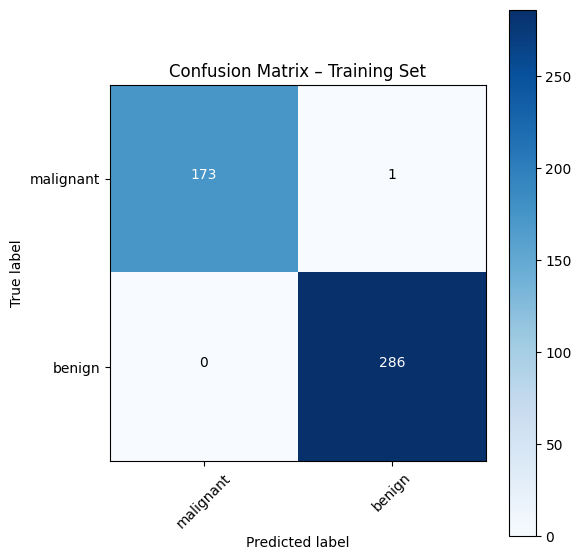

In [ ]:
# ---- Train set Classification Report and Confusion Matrix----
print("Base Model Evaluation:\n")
print("Train Classification Report")
print(classification_report(y_train, y_pred_train_base, target_names=target_names))
plot_confusion_matrix(y_train, y_pred_train_base, 'Confusion Matrix – Training Set')

* The train macro avg f1 score for the base model is 1.
* In addition, the train malignant recall for the base model is 0.99.
* The base model misclassifies only one malignant tumor as benign in the training set.

Base Model Evaluation:

Validation Classification Report
              precision    recall  f1-score   support

   malignant       0.94      0.94      0.94        17
      benign       0.97      0.97      0.97        35

    accuracy                           0.96        52
   macro avg       0.96      0.96      0.96        52
weighted avg       0.96      0.96      0.96        52



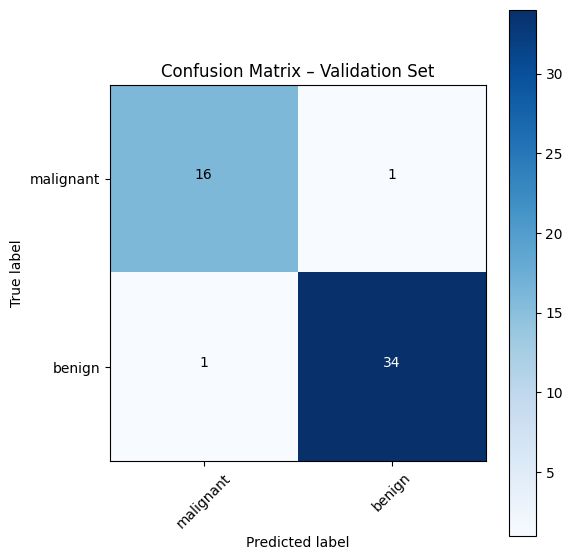

In [ ]:
# ---- Validation set Classification Report and Confusion Matrix ----
print("Base Model Evaluation:\n")
print("Validation Classification Report")
print(classification_report(y_val, y_pred_val_base, target_names=target_names))
plot_confusion_matrix(y_val, y_pred_val_base, 'Confusion Matrix – Validation Set')

* The validation macro avg f1 score for the base model is 0.96.
* In addition, the validation malignant recall for the base model is 0.94.
* In the validation set, the base model misclassifies one malignant tumor as benign and one benign tumor as malignant.

Base Model Evaluation:

Test Classification Report
              precision    recall  f1-score   support

   malignant       1.00      0.95      0.98        21
      benign       0.97      1.00      0.99        36

    accuracy                           0.98        57
   macro avg       0.99      0.98      0.98        57
weighted avg       0.98      0.98      0.98        57



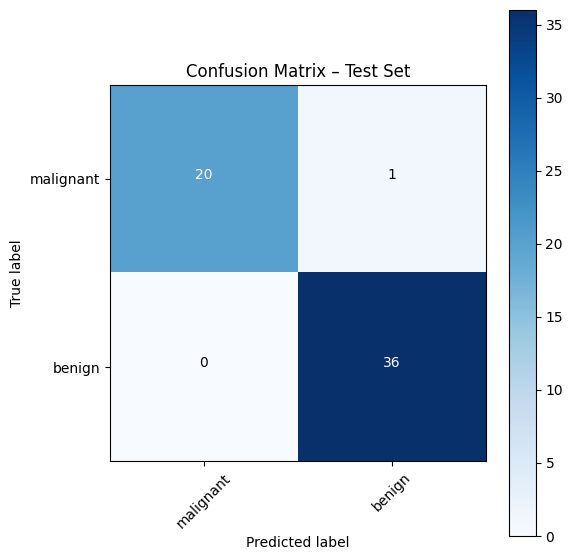

In [ ]:
# ---- Test set Classification Report and Confusion Matrix ----
print("Base Model Evaluation:\n")
print("Test Classification Report")
print(classification_report(y_test, y_pred_test_base, target_names=target_names))
plot_confusion_matrix(y_test, y_pred_test_base, 'Confusion Matrix – Test Set')

* The test macro avg f1 score for the base model is 0.98.
* In addition, the test malignant recall for the base model is 0.95.
* In the test set, the base model misclassifies one malignant tumor as benign.

###### <font color="blue"> Best Model Evaluation (Optimal Hyperparameters) </font>

In [ ]:
# load the save best model
best_model_loaded = load_model('final_model_for_project2.keras')

# make predictions for train, validation, and test datasets
y_pred_train = (best_model_loaded.predict(X_train) > 0.5).astype("int32")
y_pred_val = (best_model_loaded.predict(X_val) > 0.5).astype("int32")
y_pred_test = (best_model_loaded.predict(X_test) > 0.5).astype("int32")

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 22 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


Best Model Evaluation:

Train Classification Report
              precision    recall  f1-score   support

   malignant       0.97      0.98      0.97       174
      benign       0.99      0.98      0.98       286

    accuracy                           0.98       460
   macro avg       0.98      0.98      0.98       460
weighted avg       0.98      0.98      0.98       460



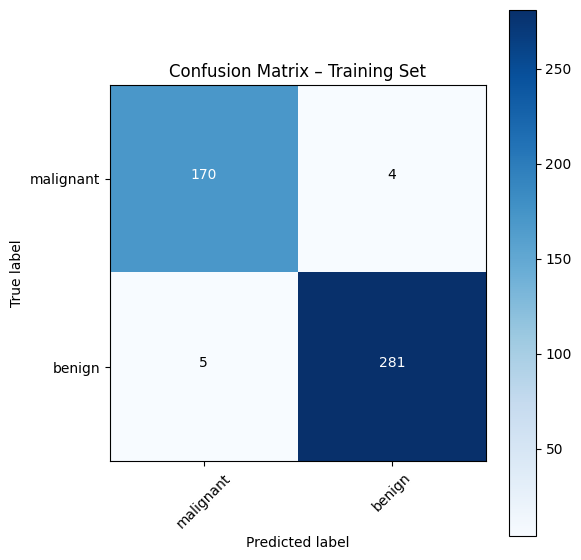

In [ ]:
# ---- Train set Classification Report and Confusion Matrix----
print("Best Model Evaluation:\n")
print("Train Classification Report")
print(classification_report(y_train, y_pred_train, target_names=target_names))
plot_confusion_matrix(y_train, y_pred_train, 'Confusion Matrix – Training Set')

* The train macro avg f1 score for the best model is 0.98.
* In addition, the train malignant recall for the best model is 0.98.
* In the train set, the best model misclassifies four malignant tumor as benign and five benign tumor as malignant.
* Both the F1 score and malignant recall have decreased compared to the base model’s results on the training set (F1 score: 1.00, malignant recall: 0.99).

Best Model Evaluation:

Validation Classification Report
              precision    recall  f1-score   support

   malignant       1.00      0.94      0.97        17
      benign       0.97      1.00      0.99        35

    accuracy                           0.98        52
   macro avg       0.99      0.97      0.98        52
weighted avg       0.98      0.98      0.98        52



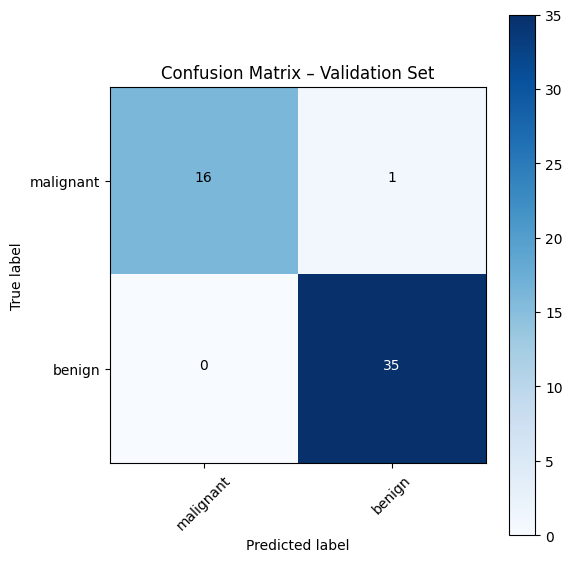

In [ ]:
# ---- Validation set Classification Report and Confusion Matrix ----
print("Best Model Evaluation:\n")
print("Validation Classification Report")
print(classification_report(y_val, y_pred_val, target_names=target_names))
plot_confusion_matrix(y_val, y_pred_val, 'Confusion Matrix – Validation Set')

* The validation macro avg f1 score for the best model is 0.98.
* In addition, the validation malignant recall for the best model is 0.94.
* In the validation set, the best model misclassifies one malignant tumor as benign while correctly classifying all benign tumors.

* Malignant precision and benign recall have both increased to a perfect 1.00 compared to the previous base model’s results on the validation set.

* The F1 score has increased compared to the previous base model’s F1 score on the validation set (0.96).

Best Model Evaluation:

Test Classification Report
              precision    recall  f1-score   support

   malignant       1.00      0.95      0.98        21
      benign       0.97      1.00      0.99        36

    accuracy                           0.98        57
   macro avg       0.99      0.98      0.98        57
weighted avg       0.98      0.98      0.98        57



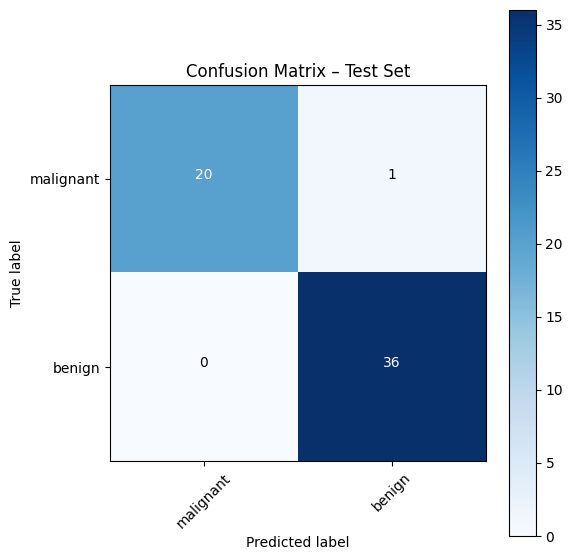

In [ ]:
# ---- Test set Classification Report and Confusion Matrix ----
print("Best Model Evaluation:\n")
print("Test Classification Report")
print(classification_report(y_test, y_pred_test, target_names=target_names))
plot_confusion_matrix(y_test, y_pred_test, 'Confusion Matrix – Test Set')


* The test macro avg f1 score for the best model is 0.98.
* In addition, the test malignant recall for the best model is 0.95.
* In the test set, the best model misclassifies one malignant tumor as benign.


###### <font color="blue"> Conclusion  </font>

* Both the base and tuned models achieved outstanding test performance, with an identical F1-score of 0.98.

* While the test F1-score did not differ between the two models, the tuned model’s training F1 decreased slightly from a perfect 1.00 to 0.98, and malignant recall from 0.99 to 0.98.

* Conversely, the validation F1 improved from 0.963 to 0.986, with all benign tumours correctly classified.

* This improvement suggests that the tuned model was better optimised for generalisation, reducing overfitting risk.

* Notably, the number of hidden nodes was moderately increased from 20 to 25, and combined with an appropriate learning rate, this adjustment enhanced the model’s learning capacity without causing overfitting.

* Therefore, the tuned model is likely to be more robust in real-world scenarios, and will be used in Q5 when comparing the logistic regression model with the ANN model.



---





---



---



---



# <font color="green">**Model Comparison and Safety Evaluation**</font>




### **5.1 Comparative Test**



* In Project 1, we built the **logistic regression classifier**. The optimal hyperparameters were determined via grid search with 4-fold cross-validation, using the F1 score as the selection metric.

* The final configuration was:

  * C = 0.5
  * penalty = ‘l2’
  * class_weight = {1: 0.6, 0: 0.4}

* This configuration achieved a **0.957** test F1 score.

The followings are pros and cons of logistic regression model:

* **Strengths**

  * Interpretability: Coefficients in logistic regression have clear meaning (odds ratios), aiding clinical acceptance.

  * Computational efficiency: logistic regression is fast to train and deploy, even on limited hardware and data.

  * Class imbalance handling: logistic regression supports straightforward class imbalance weighting using the class_weight hyperparameter.

* **Limitations**

  * Linear assumption: logistic regression assumes a linear relationship between features and the log-odds of the target not capturing non-linear pattern.

  * Limited feature interaction: logistic regression requires explicit creation of interaction terms to capture dependencies between variables.


  * Our recommendation was to **deploy** this model in a clinical decision-support setting, under cautious monitoring for the potential considerable clinical consequences of misclassification in high-risk cases and due to the linearity assumption, which may limit detection of complex patterns.

* **Strengths**

  * In the **ANN model**, we achieved a **0.98** test F1 score. The ANN model shows better performance compared to the logistic regression model. The test F1 score has increased to 0.98 from 0.957. Therefore, in terms of performance the ANN model is preferable in healthcare contexts where a correct diagnosis is important.

  * ANN model is able to capture complex and non-linear relationships between features, unlike the logistic regression model, which assumes a linear relationship. Therefore, the ANN model is beneficial in the healthcare context where complex and diverse data types such as image, text, and tabular data, as well as heterogeneous data are often used.

  * Furthermore, the ANN model not only learns explicit features but also learns implicit feature combinations, such as interaction data, without requiring manual feature engineering, unlike logistic regression, which requires manual creation of features. This enables the model to better capture the relationship between predictors and the independent variable, enhancing the prediction.


* **Limitatons**

  * While ANN generally shows better performance by capturing complex relationships and due to its versatility to various data types, it lacks interpretation compared to the logistic regression model. It is hard to explain predictions from the ANN model to a clinician.

  * In addition, the deep learning model, ANN, often requires a larger dataset for model generalisation and so requires more computational cost.

  * Furthermore, ANN models are sensitive to class imbalance which can lead to performance degradation for minority classes.  This is particularly important in healthcare applications, where minority class predictions often represent critical cases.


* I would recommend deploying the **ANN** model because it achieved a higher test F1 score (0.98) compared to the logistic regression model (0.957). The correct diagnosis have a direct effect on the patient outcome and overall lose of the patient's mental, physical and financial well-being hence in healthcare even small performance gains can be clinically significant.


* Since the ANN model is capable of capturing intricate, and non-linear  relationships between features, it is suitable to heterogeneous healthcare data modalities including medical images, text and tabular records or combinations these. This is common within medical research, where many relationships are of non-linear nature.


* Regardless of its high computational resources and large datasets demands, ANN justifies the investment by its relevance in life-threatening conditions, and overfitting prevention hence providing more accurate real-world diagnoses.


* While interpretability is lower than the logistic regression, the improvement in predictive performance, along with its versatility across various data types and its ability to capture complex patterns, supports its use when accuracy is the top priority.  If interpretability is a concern, logistic regression could be used for cross-validation with clinical judgment as a secondary model.


### **5.2 Communicating Uncertainty and Confidence**

Describe how you would communicate uncertainty or prediction confidence to stakeholders (e.g. clinicians, patients, IT staff). </font>



* I would communicate in a language that each stakeholder understood according to each expertise and role.



* **Clinicians Communication**:

  * Clinicians would be provided with prediction confidence scores (e.g., probability of malignancy) along with 95% confidence intervals and the key features used in the model. In addition, visual aids such as probability bars, calibration plots, or risk stratification charts would be presented. Clinicians would be reminded that predictions are supportive tools, not definitive conclusions, and must be combined with clinical judgment.



* **Patients Communication:**

  * Patients should be presented with results in clear, non-technical language, clarifying that the model assists but does not replace clinical judgment. When communicating with patients, qualitative terms (“high confidence,” “moderate confidence,” “low confidence”) should be used rather than raw percentages. For example: “Based on the available data, there’s a high likelihood this is malignant. Your doctor will confirm this with further tests.” Furthermore, simple graphics like color-coded scales (green/yellow/red) would be used to show the risk and what actions should follow.



* **IT Staff Communication:**

  * IT staff would be provided with the saved model and description of the model’s deployment, including success criteria, preprocessing steps, hyperparameter settings, model structure for reproducibility. We will also provide the training, validation and test set confusion matrices along with classification reports  to verify reliability and prediction confidence.  The key sources of uncertainty (e.g., data variability, class imbalances), as well as monitoring tools would be provided to track both the uncertainty and performance over time ensuring early detection of potential shifts.





### **5.3 Design Improvements and Risk Mitigation Strategies**

Propose any design changes, deployment strategies, or safeguards that could help reduce risks, improve trust, and ensure safe and responsible use of the model in clinical practice.

* **Model Update and Continuous Monitoring**

  * Using larger and more diverse datasets would help improve the model’s generalizability. Real-world performance should be periodically monitored for the model and the models should be regularly updated  with newly collected clinical data to adapt to evolving patient demographics, updated medical trends ,and guidelines.


* **Interpretation and Transparency Enhancements**

  * The system should integrate explainable AI methods such as SHAP or LIME to show clinicians which features influenced predictions and to what extent.

  * The model’s limitations and uncertainty should be clearly communicated to enable clinicians to integrate model outputs appropriately with their own judgment.


* **Risk Mitigation through Human-in-the-Loop**

  * Qualified clinicians should review all model predictions and appropriate escalation protocols are invoked for cases of low-confidence/ abnormal outputs


* **Security and Privacy**

  * Strict data privacy should be applied including data encryption, secure storage, and controlled access.

  * Model deployment pipelines should be secured to prevent tampering, unauthorized updates and adversarial attacks.



